# Demo: Face Anti-Spoofing Classification

Цей ноутбук дозволяє завантажити зображення обличчя та отримати результат класифікації від трьох натренованих моделей:
1. **LBP + SVM** (baseline)
2. **SpoofCNN** (CNN з нуля)
3. **MobileNetV2** (fine-tuning)

## Використання
1. Запустіть усі комірки
2. Вкажіть шлях до зображення у відповідній комірці
3. Отримайте результати класифікації від усіх трьох моделей

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

# Визначаємо пристрій (MPS для Apple Silicon, інакше CPU)
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

# Базова директорія (де лежать моделі)
BASE_DIR = Path('.') 
MODELS_DIR = BASE_DIR / 'models'
print(f'Models directory: {MODELS_DIR.resolve()}')

Device: mps
Models directory: /Users/darwin/edu/cnn-face-antispoofing-2d/models


## 1. Визначення архітектур моделей

In [3]:
# ============ SpoofCNN (CNN з нуля) ============

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class SpoofCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


print('\u2713 SpoofCNN architecture defined')

✓ SpoofCNN architecture defined


In [4]:
# ============ MobileNetV2 (fine-tuned) ============

def build_mobilenet():
    """Створює MobileNetV2 з кастомним класифікатором (як при тренуванні)."""
    backbone = models.mobilenet_v2(weights=None)
    in_features = backbone.classifier[1].in_features  # 1280
    backbone.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, 2)
    )
    return backbone


print('\u2713 MobileNetV2 builder defined')

✓ MobileNetV2 builder defined


In [5]:
# ============ LBP Descriptor (як при тренуванні) ============

class LBPDescriptor:
    """Local Binary Pattern descriptor (uniform patterns)."""
    
    def __init__(self, points=8, radius=1):
        self.points = points
        self.radius = radius
    
    def _get_pixel(self, img, center, x, y):
        """Get pixel value with bounds checking."""
        h, w = img.shape
        x = min(max(x, 0), w - 1)
        y = min(max(y, 0), h - 1)
        return img[y, x]
    
    def compute_lbp(self, img):
        """Compute LBP image."""
        if len(img.shape) == 3:
            img = np.mean(img, axis=2).astype(np.uint8)
        
        h, w = img.shape
        lbp_img = np.zeros((h, w), dtype=np.uint8)
        
        for i in range(self.radius, h - self.radius):
            for j in range(self.radius, w - self.radius):
                center = img[i, j]
                binary_string = 0
                
                for p in range(self.points):
                    angle = 2 * np.pi * p / self.points
                    x = j + int(round(self.radius * np.cos(angle)))
                    y = i - int(round(self.radius * np.sin(angle)))
                    
                    pixel = self._get_pixel(img, (j, i), x, y)
                    if pixel >= center:
                        binary_string |= (1 << p)
                
                lbp_img[i, j] = binary_string
        
        return lbp_img
    
    def compute_histogram(self, img, n_bins=59):
        """Compute normalized uniform LBP histogram."""
        lbp_img = self.compute_lbp(img)
        
        # Uniform pattern mapping
        def is_uniform(val, points):
            binary = format(val, f'0{points}b')
            transitions = sum(binary[i] != binary[i+1] for i in range(len(binary)-1))
            transitions += (binary[-1] != binary[0])
            return transitions <= 2
        
        # Build uniform pattern lookup
        uniform_map = {}
        uniform_idx = 0
        for val in range(2**self.points):
            if is_uniform(val, self.points):
                uniform_map[val] = uniform_idx
                uniform_idx += 1
        non_uniform_idx = uniform_idx  # all non-uniform go to last bin
        
        # Compute histogram
        hist = np.zeros(n_bins, dtype=np.float64)
        for val in lbp_img.flatten():
            if val in uniform_map:
                hist[uniform_map[val]] += 1
            else:
                if non_uniform_idx < n_bins:
                    hist[non_uniform_idx] += 1
        
        # Normalize
        total = hist.sum()
        if total > 0:
            hist /= total
        
        return hist


print('\u2713 LBP Descriptor defined')

✓ LBP Descriptor defined


## 2. Завантаження натренованих моделей

In [6]:
# --- Завантаження LBP + SVM ---
lbp_svm_path = MODELS_DIR / 'lbp_svm_model.pkl'
lbp_svm_data = joblib.load(lbp_svm_path)

svm_model = lbp_svm_data['svm']
svm_scaler = lbp_svm_data['scaler']
lbp_params = lbp_svm_data['lbp_params']
svm_threshold = lbp_svm_data['threshold']

lbp_descriptor = LBPDescriptor(
    points=lbp_params.get('points', 8),
    radius=lbp_params.get('radius', 1)
)

print(f'\u2713 LBP+SVM loaded (threshold={svm_threshold:.4f})')
print(f'  LBP params: points={lbp_params.get("points", 8)}, radius={lbp_params.get("radius", 1)}')

✓ LBP+SVM loaded (threshold=0.7746)
  LBP params: points=8, radius=1


In [8]:
# --- Завантаження SpoofCNN ---
cnn_model = SpoofCNN(num_classes=2, dropout=0.5).to(DEVICE)
cnn_state = torch.load(MODELS_DIR / 'cnn_scratch_best.pth', map_location=DEVICE, weights_only=True)
cnn_model.load_state_dict(cnn_state)
cnn_model.eval()

print(f'\u2713 SpoofCNN loaded ({sum(p.numel() for p in cnn_model.parameters()):,} params)')

✓ SpoofCNN loaded (422,050 params)


In [9]:
# --- Завантаження MobileNetV2 ---
mobilenet_model = build_mobilenet().to(DEVICE)
mobilenet_state = torch.load(MODELS_DIR / 'mobilenet_best.pth', map_location=DEVICE, weights_only=True)
mobilenet_model.load_state_dict(mobilenet_state)
mobilenet_model.eval()

print(f'\u2713 MobileNetV2 loaded ({sum(p.numel() for p in mobilenet_model.parameters()):,} params)')

✓ MobileNetV2 loaded (2,552,322 params)


## 3. Preprocessing та inference функції

In [10]:
# Трансформації для CNN моделей (як при тренуванні)
IMG_SIZE = 128

cnn_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


def classify_lbp_svm(image_path):
    """Класифікація зображення за допомогою LBP + SVM."""
    img = np.array(Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
    
    # Обчислюємо LBP гістограму
    hist = lbp_descriptor.compute_histogram(img)
    
    # Масштабування
    hist_scaled = svm_scaler.transform(hist.reshape(1, -1))
    
    # Отримуємо score (відстань до гіперплощини)
    score = svm_model.decision_function(hist_scaled)[0]
    
    # Класифікація за порогом
    prediction = 'REAL' if score >= svm_threshold else 'ATTACK'
    confidence = abs(score - svm_threshold)
    
    return {
        'model': 'LBP + SVM',
        'prediction': prediction,
        'score': score,
        'threshold': svm_threshold,
        'confidence': confidence
    }


def classify_cnn(image_path):
    """Класифікація зображення за допомогою SpoofCNN."""
    img = Image.open(image_path).convert('RGB')
    tensor = cnn_transform(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = cnn_model(tensor)
        probs = torch.softmax(output, dim=1)[0]
    
    # class 0 = real, class 1 = attack
    pred_class = probs.argmax().item()
    prediction = 'REAL' if pred_class == 0 else 'ATTACK'
    confidence = probs[pred_class].item()
    
    return {
        'model': 'SpoofCNN (з нуля)',
        'prediction': prediction,
        'prob_real': probs[0].item(),
        'prob_attack': probs[1].item(),
        'confidence': confidence
    }


def classify_mobilenet(image_path):
    """Класифікація зображення за допомогою MobileNetV2."""
    img = Image.open(image_path).convert('RGB')
    tensor = cnn_transform(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = mobilenet_model(tensor)
        probs = torch.softmax(output, dim=1)[0]
    
    # class 0 = real, class 1 = attack
    pred_class = probs.argmax().item()
    prediction = 'REAL' if pred_class == 0 else 'ATTACK'
    confidence = probs[pred_class].item()
    
    return {
        'model': 'MobileNetV2 (fine-tuned)',
        'prediction': prediction,
        'prob_real': probs[0].item(),
        'prob_attack': probs[1].item(),
        'confidence': confidence
    }


def classify_image(image_path):
    """Запускає класифікацію через усі три моделі та показує результати."""
    image_path = Path(image_path)
    
    if not image_path.exists():
        print(f'\u274c Файл не знайдено: {image_path}')
        return
    
    # Показуємо зображення
    img = Image.open(image_path).convert('RGB')
    
    # Запускаємо моделі
    results = []
    results.append(classify_lbp_svm(image_path))
    results.append(classify_cnn(image_path))
    results.append(classify_mobilenet(image_path))
    
    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Зображення
    axes[0].imshow(img)
    axes[0].set_title(f'Input: {image_path.name}', fontsize=12)
    axes[0].axis('off')
    
    # Результати
    axes[1].axis('off')
    result_text = 'РЕЗУЛЬТАТИ КЛАСИФІКАЦІЇ\n' + '=' * 40 + '\n\n'
    
    for r in results:
        emoji = '\u2705' if r['prediction'] == 'REAL' else '\U0001f6a8'
        result_text += f"{emoji} {r['model']}:\n"
        result_text += f"   Результат: {r['prediction']}\n"
        
        if 'prob_real' in r:
            result_text += f"   P(real)={r['prob_real']:.4f}  P(attack)={r['prob_attack']:.4f}\n"
        else:
            result_text += f"   Score={r['score']:.4f}  Threshold={r['threshold']:.4f}\n"
        result_text += '\n'
    
    # Консенсус
    votes = [r['prediction'] for r in results]
    consensus = 'REAL' if votes.count('REAL') >= 2 else 'ATTACK'
    result_text += '-' * 40 + '\n'
    result_text += f"КОНСЕНСУС (голосування): {consensus}\n"
    result_text += f"  ({votes.count('REAL')}/3 моделей = REAL)"
    
    axes[1].text(0.05, 0.95, result_text, transform=axes[1].transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return results


print('\u2713 Classification functions ready')

✓ Classification functions ready


## 4. Класифікація зображень

Вкажіть шлях до зображення нижче. Можна використовувати:
- Абсолютний шлях: `/path/to/image.png`
- Відносний шлях від цієї папки: `datasets/replayattack/train/real/client001_session01_webcam_authenticate_adverse_1/frame_42.png`

/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


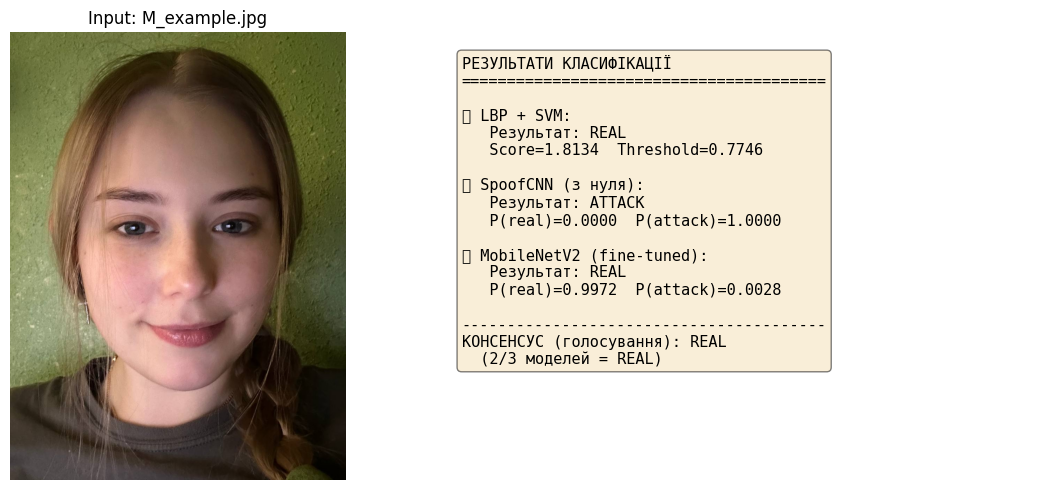

In [11]:
# ========== ВКАЖІТЬ ШЛЯХ ДО ЗОБРАЖЕННЯ ==========

image_path = "M_example.jpg"
# Запускаємо класифікацію
results = classify_image(image_path)

## 5. Пакетна класифікація кількох зображень

Можна передати список шляхів для порівняння кількох зображень одразу.

Класифікація 4 зображень...


📷 M_example_1.jpg
----------------------------------------------------------------------


/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


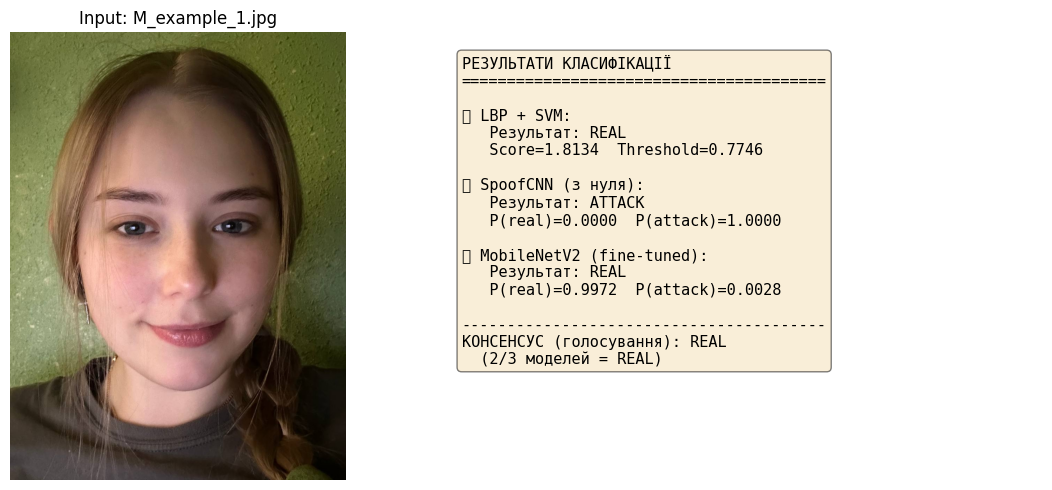



📷 M_example_2.jpg
----------------------------------------------------------------------


/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


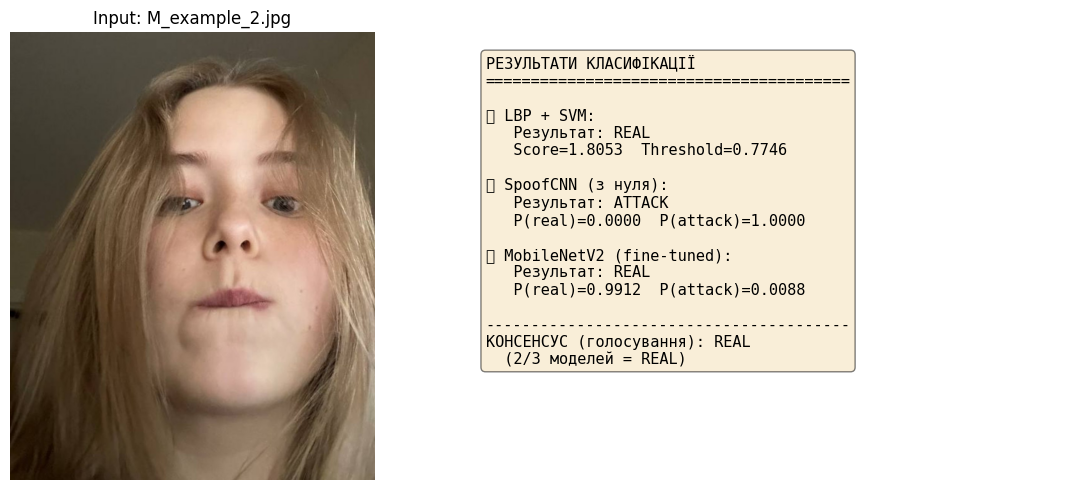



📷 N_example_1.jpg
----------------------------------------------------------------------


/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


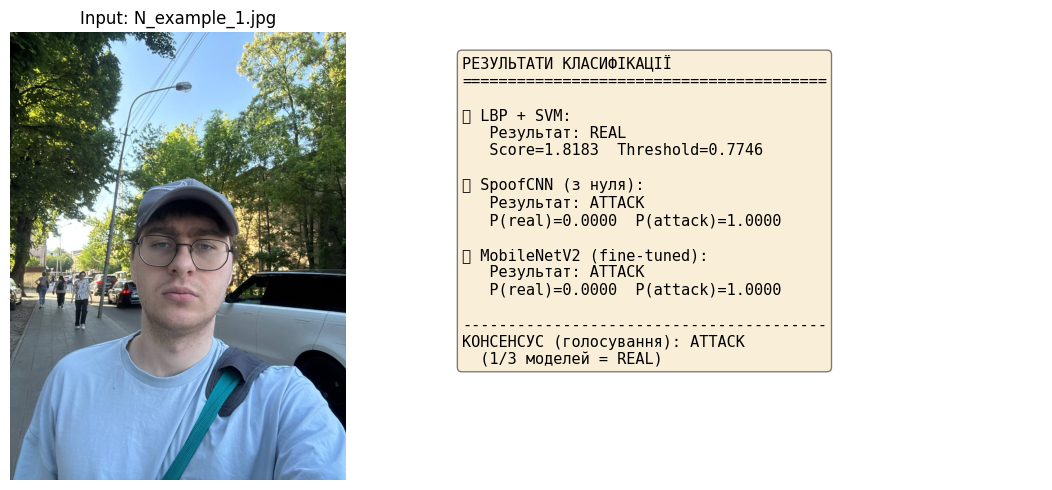



📷 N_example_2.png
----------------------------------------------------------------------


/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/vl/0cq2f9cx5td1_z5sy6g7kdwh0000gn/T/ipykernel_51993/2921509633.py:135: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/darwin/edu/cnn-face-antispoofing-2d/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


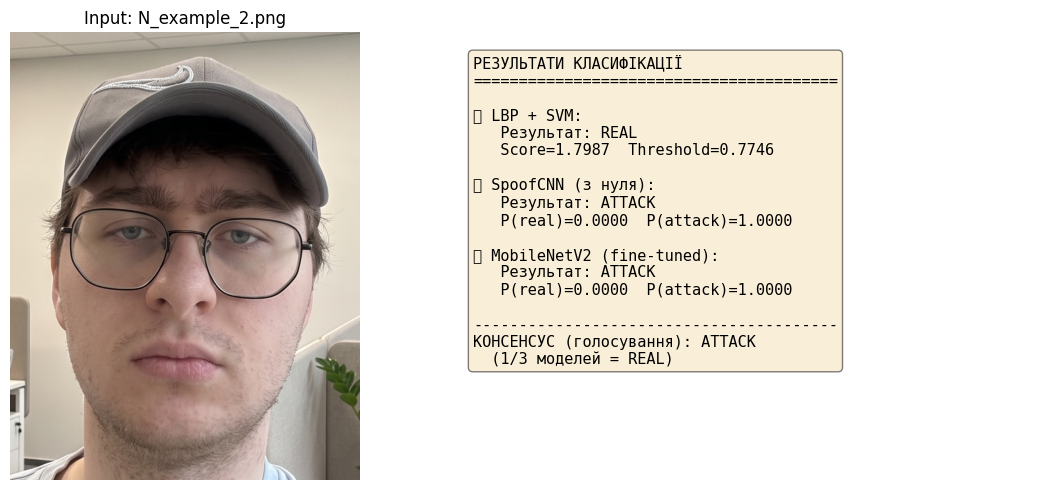

In [14]:
# ========== ПАКЕТНА КЛАСИФІКАЦІЯ ==========

# Вкажіть список шляхів до зображень
image_paths = [
    "M_example_1.jpg",
    "M_example_2.jpg",
    "N_example_1.jpg",
    "N_example_2.png",
]

print(f'Класифікація {len(image_paths)} зображень...\n')
print('=' * 70)

all_results = []
for path in image_paths:
    print(f'\n\U0001f4f7 {Path(path).name}')
    print('-' * 70)
    result = classify_image(path)
    if result:
        all_results.append({'path': path, 'results': result})
    print()

## 6. Зведена таблиця результатів

In [26]:
# Показуємо зведену таблицю якщо є результати
if all_results:
    print(f"{'Файл':<50} {'LBP+SVM':<10} {'CNN':<10} {'MobileNet':<10} {'Консенсус':<10}")
    print('=' * 90)
    
    for item in all_results:
        fname = Path(item['path']).name
        r = item['results']
        votes = [x['prediction'] for x in r]
        consensus = 'REAL' if votes.count('REAL') >= 2 else 'ATTACK'
        
        print(f"{fname:<50} {r[0]['prediction']:<10} {r[1]['prediction']:<10} {r[2]['prediction']:<10} {consensus:<10}")
else:
    print('Немає результатів. Спочатку запустіть пакетну класифікацію вище.')

Файл                                               LBP+SVM    CNN        MobileNet  Консенсус 
frame_0207.jpg                                     REAL       REAL       ATTACK     REAL      
frame_0106.jpg                                     REAL       ATTACK     ATTACK     ATTACK    
frame_0101.jpg                                     REAL       ATTACK     ATTACK     ATTACK    
